# Imports

In [1]:
import time
import bios
import pandas as pd
import numpy as np
import sklearn as sk
from sklearn.linear_model import LinearRegression

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from torch import nn
from sklearn.cluster import KMeans, DBSCAN, OPTICS
from Autoencoder_classes import Encoder, Decoder, GOAE, ClusteringLayer, extract_latent_space, orthogonality_loss

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from torch import nn
from sklearn.cluster import KMeans

from sklearn.metrics import adjusted_rand_score, accuracy_score, recall_score, f1_score, precision_score

# Testing aggregated models:

In [24]:
df = pd.read_csv('data/real_dataset_normalized_by_cptac.tsv', sep = '\t', index_col=0)
conditions = df.T.drop(columns=['Conditions'])
df = df.T.drop(columns=['Conditions'])
sample_data_normalized = df.reset_index(drop=True).to_numpy(dtype=np.float32)
sample_data_normalized = np.nan_to_num(sample_data_normalized)
proteomics_tensor = torch.tensor(sample_data_normalized, dtype=torch.float32)

input_dim = proteomics_tensor.shape[1]

latent_dim = 10
hidden_dim_1 = 500
hidden_dim_2 = 2000
hidden_dim_3 = 500
n_clusters = 2
autoencoder = GOAE(input_dim, latent_dim, hidden_dim_1=hidden_dim_1, hidden_dim_2=hidden_dim_2, hidden_dim_3=hidden_dim_3)
#clustering_layer = ClusteringLayer(n_clusters, latent_dim)



# Initialize optimizers
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)
#autoencoder.load_state_dict(torch.load('data/tests/5 client test cptac normalization/_state_dict_client4', weights_only=True))
autoencoder.load_state_dict(torch.load('data/tests/5 client test cptac normalization/_state_dict_client3', weights_only=True))

latent_representations = extract_latent_space(autoencoder, proteomics_tensor)
n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=22)
clusters = kmeans.fit_predict(latent_representations)

conditions = pd.read_csv('data/real_dataset_normalized.tsv', sep = '\t', index_col=0)
conditions = conditions.T.iloc[:, -1]
conditions = conditions.dropna();
conditions

C:\Users\david\AppData\Local\Temp\ipykernel_22084\2374973456.py:1: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/real_dataset_normalized_by_cptac.tsv', sep = '\t', index_col=0)
C:\Users\david\AppData\Local\Temp\ipykernel_22084\2374973456.py:30: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83

01CPTAC_1             Not Reported
01CPTAC_2            Primary Tumor
01CPTAC_3            Primary Tumor
01CPTAC_4            Primary Tumor
01CPTAC_5            Primary Tumor
                      ...         
13CPTAC_6            Primary Tumor
13CPTAC_7            Primary Tumor
13CPTAC_8            Primary Tumor
13CPTAC_9      Solid Tissue Normal
13CPTAC_10     Solid Tissue Normal
Name: Conditions, Length: 130, dtype: object

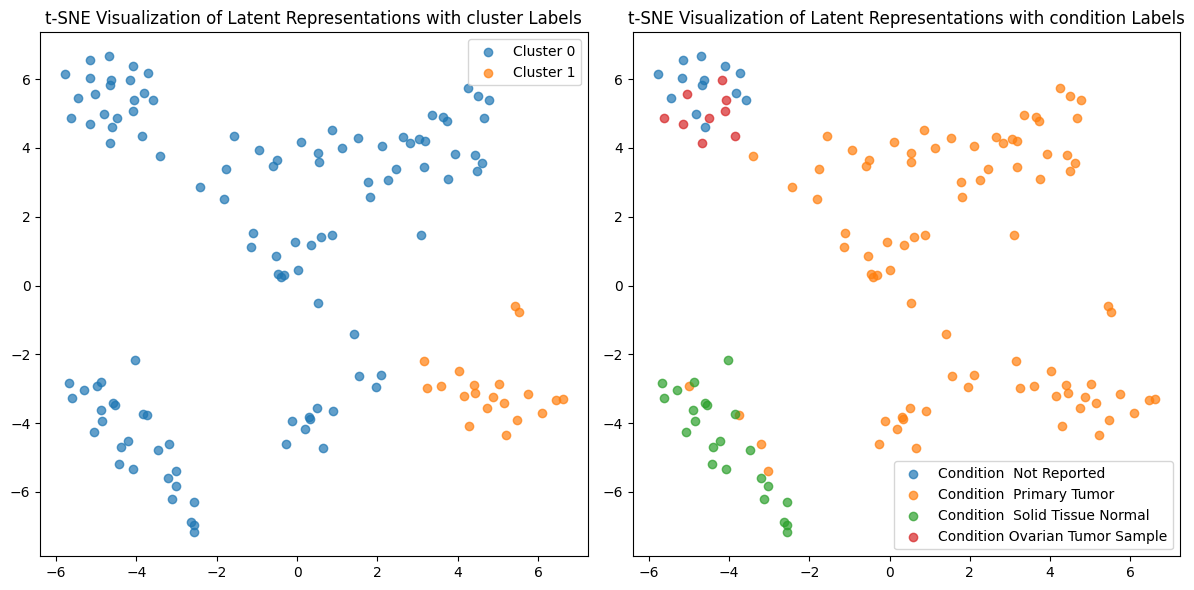

In [25]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=0)
latent_2d = tsne.fit_transform(latent_representations)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for cluster in set(clusters):
    indices = (clusters == cluster)
    axes[0].scatter(latent_2d[indices, 0], latent_2d[indices, 1], label=f'Cluster {cluster}', alpha=0.7)
axes[0].set_title('t-SNE Visualization of Latent Representations with cluster Labels')
axes[0].legend()

conditions = conditions.values
unique_conditions = np.unique(conditions)
for condition in unique_conditions:
    indices = (conditions == condition)
    axes[1].scatter(
        latent_2d[indices, 0],
        latent_2d[indices, 1],
        label=f'Condition {condition}',
        alpha=0.7
    )
axes[1].set_title('t-SNE Visualization of Latent Representations with condition Labels')
axes[1].legend()

plt.tight_layout()
plt.show()

# Evaluation


In [26]:
index = (conditions ==' Primary Tumor') + (conditions == ' Solid Tissue Normal')

filtered_space = latent_representations[index, :]
filtered_conditions = conditions[index]

n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=22)
dbscan = DBSCAN(eps=0.06)
optics = OPTICS(min_samples=5, xi=0.085, min_cluster_size=0.05)

dbscan_clustering = dbscan.fit(filtered_space).labels_
optics_clustering = optics.fit(filtered_space).labels_
kmeans_clustering = kmeans.fit(filtered_space).labels_


3 Client Test

In [27]:
condition_map = {
    ' Primary Tumor' : 0,
    ' Solid Tissue Normal' : 1
}

encoded_conditions = np.vectorize(condition_map.get)(filtered_conditions)
equality1 = encoded_conditions == kmeans_clustering
equality2 = encoded_conditions != kmeans_clustering
# swich if cluster lables (name of cluster is random)
if np.sum(equality1) < np.sum(equality2):
    encoded_conditions = -1*encoded_conditions + 1


accuracy = accuracy_score(kmeans_clustering, encoded_conditions)
recall = recall_score(kmeans_clustering, encoded_conditions)
f1 = f1_score(kmeans_clustering, encoded_conditions)
precision = precision_score(kmeans_clustering, encoded_conditions)

print(f"Accuracy: {accuracy}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"Precision: {precision}")

Accuracy: 0.9166666666666666
Recall: 0.9871794871794872
F1 Score: 0.9447852760736196
Precision: 0.9058823529411765
